In [1]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, zipfile, shutil
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)
print("All imports done!")

TensorFlow: 2.20.0
All imports done!


In [8]:
import os, shutil

src = '/content/drive/MyDrive/ai_project_synthetic_datasets-20260505T171228Z-3-001/ai_project_synthetic_datasets'

if os.path.exists('raw_data'):
    shutil.rmtree('raw_data')

shutil.copytree(src, 'raw_data/ai_project_synthetic_datasets')

print("Copy done!")
print(os.listdir('raw_data/ai_project_synthetic_datasets'))

Copy done!
['part_4_ai_solution_design', 'part_1_neural_network_analysis', 'README.md', 'part_2_cnn_computer_vision', 'part_3_nlp_sequence_modeling', '.DS_Store', 'manifest.json']


In [9]:
# Organize images into class folders
labels_df = pd.read_csv('raw_data/ai_project_synthetic_datasets/part_2_cnn_computer_vision/labels.csv')
print("Labels CSV shape:", labels_df.shape)
print(labels_df.head())
print("\nClass distribution:")
print(labels_df['class'].value_counts())

# Source base path
base_src = 'raw_data/ai_project_synthetic_datasets/part_2_cnn_computer_vision/'

# Create train/test folder structure
for split in ['train', 'test']:
    for cls in labels_df['class'].unique():
        os.makedirs(f'dataset/{split}/{cls}', exist_ok=True)

# Split: 80% train, 20% test per class
from sklearn.model_selection import train_test_split

for cls in labels_df['class'].unique():
    class_files = labels_df[labels_df['class'] == cls]['filename'].tolist()
    train_files, test_files = train_test_split(class_files, test_size=0.2, random_state=42)

    for f in train_files:
        src = os.path.join(base_src, f)
        dst = f'dataset/train/{cls}/{os.path.basename(f)}'
        if os.path.exists(src):
            shutil.copy(src, dst)

    for f in test_files:
        src = os.path.join(base_src, f)
        dst = f'dataset/test/{cls}/{os.path.basename(f)}'
        if os.path.exists(src):
            shutil.copy(src, dst)

print("\nDataset organized!")
for split in ['train', 'test']:
    for cls in os.listdir(f'dataset/{split}'):
        count = len(os.listdir(f'dataset/{split}/{cls}'))
        print(f"  {split}/{cls}: {count} images")

Labels CSV shape: (480, 2)
                       filename   class
0  images/normal/normal_001.png  normal
1  images/normal/normal_002.png  normal
2  images/normal/normal_003.png  normal
3  images/normal/normal_004.png  normal
4  images/normal/normal_005.png  normal

Class distribution:
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64

Dataset organized!
  train/scratch: 96 images
  train/stain: 96 images
  train/normal: 96 images
  train/dent: 96 images
  test/scratch: 24 images
  test/stain: 24 images
  test/normal: 24 images
  test/dent: 24 images


Classes: ['dent', 'normal', 'scratch', 'stain']
Number of classes: 4
  dent: 96 train | 24 test
  normal: 96 train | 24 test
  scratch: 96 train | 24 test
  stain: 96 train | 24 test


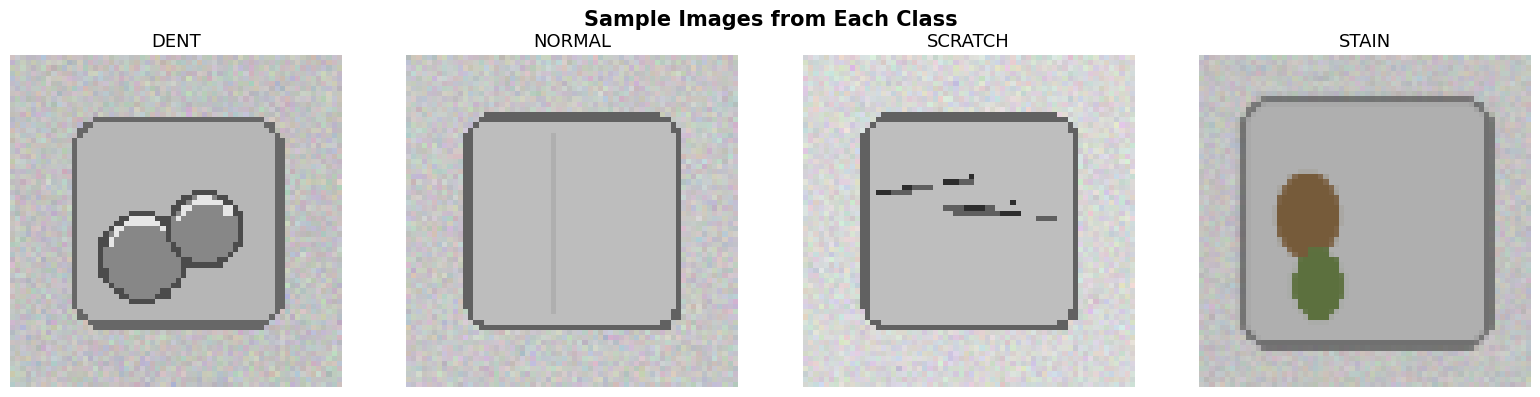

Sample images saved!

Sample image size: (96, 96)
We will resize all images to: 64x64


In [10]:
# Dataset Exploration
os.makedirs('results', exist_ok=True)
os.makedirs('sample_predictions', exist_ok=True)

classes = sorted(os.listdir('dataset/train'))
print("Classes:", classes)
print("Number of classes:", len(classes))

# Count images
for cls in classes:
    train_count = len(os.listdir(f'dataset/train/{cls}'))
    test_count  = len(os.listdir(f'dataset/test/{cls}'))
    print(f"  {cls}: {train_count} train | {test_count} test")

# Show sample images from each class
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, cls in enumerate(classes):
    img_path = f"dataset/train/{cls}/{os.listdir(f'dataset/train/{cls}')[0]}"
    img = load_img(img_path, target_size=(64, 64))
    axes[i].imshow(img)
    axes[i].set_title(cls.upper(), fontsize=13)
    axes[i].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('results/sample_class_images.png', dpi=100, bbox_inches='tight')
plt.show()
print("Sample images saved!")

# Image dimensions check
sample_img_path = f"dataset/train/{classes[0]}/{os.listdir(f'dataset/train/{classes[0]}')[0]}"
sample_img = load_img(sample_img_path)
print(f"\nSample image size: {sample_img.size}")
print(f"We will resize all images to: 64x64")

In [11]:
# Image Preprocessing using ImageDataGenerator
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

# Train generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Test generator - only rescale
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    'dataset/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nClass indices:", train_generator.class_indices)
print(f"Train batches: {len(train_generator)}")
print(f"Test batches: {len(test_generator)}")

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.

Class indices: {'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}
Train batches: 12
Test batches: 3


In [12]:
#  CNN Model Creation
num_classes = len(classes)

model = keras.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),

    # Dense layers
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f"\nTotal params: {model.count_params():,}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,237,860 (8.54 MB)

 Trainable params: 2,237,860 (8.54 MB)

 Non-trainable params: 0 (0.00 B)


Total params: 2,237,860


In [13]:
# Train the CNN Model
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator,
    verbose=1
)

print("\nTraining complete!")
print(f"Final Train Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Val Accuracy:   {history.history['val_accuracy'][-1]*100:.2f}%")

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 843ms/step - accuracy: 0.2396 - loss: 1.3953 - val_accuracy: 0.2500 - val_loss: 1.3860
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 919ms/step - accuracy: 0.2344 - loss: 1.3865 - val_accuracy: 0.3333 - val_loss: 1.3857
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.2891 - loss: 1.3860 - val_accuracy: 0.6146 - val_loss: 1.3836
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 753ms/step - accuracy: 0.2812 - loss: 1.3824 - val_accuracy: 0.3542 - val_loss: 1.3633
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 949ms/step - accuracy: 0.3151 - loss: 1.3319 - val_accuracy: 0.5938 - val_loss: 1.1327
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 941ms/step - accuracy: 0.5312 - loss: 1.0779 - val_accuracy: 0.8125 - val_loss: 0.6932
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 842ms/step - accuracy: 0.6953 - loss: 0.7287 - val_accuracy: 0.7396 - val_loss: 0.5744
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 788ms/step - accuracy: 0.7161 - loss: 0.6638 - val_accuracy

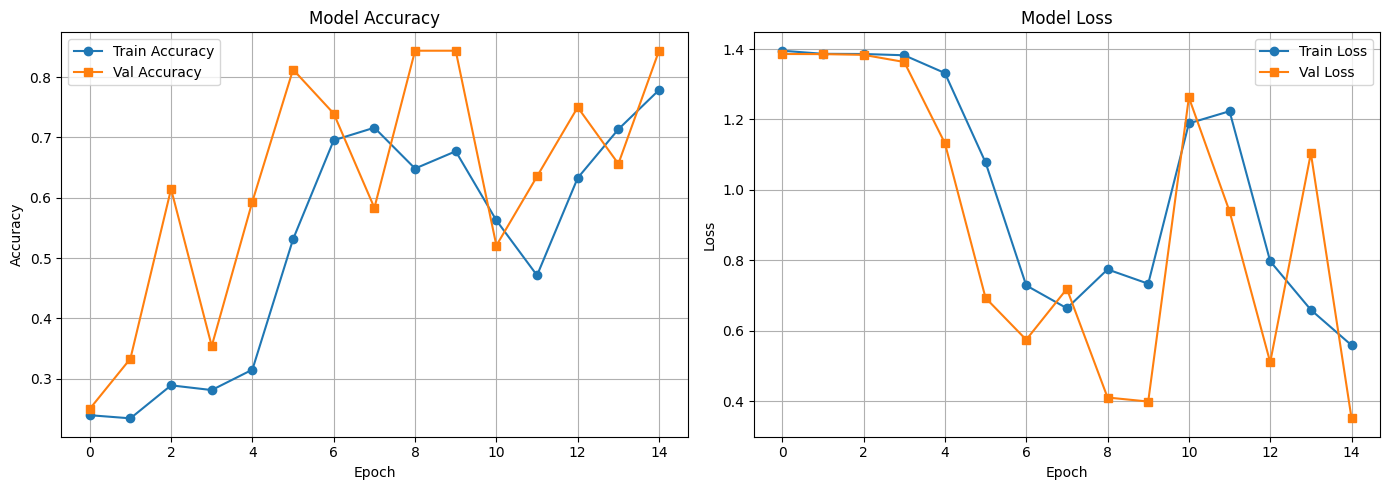

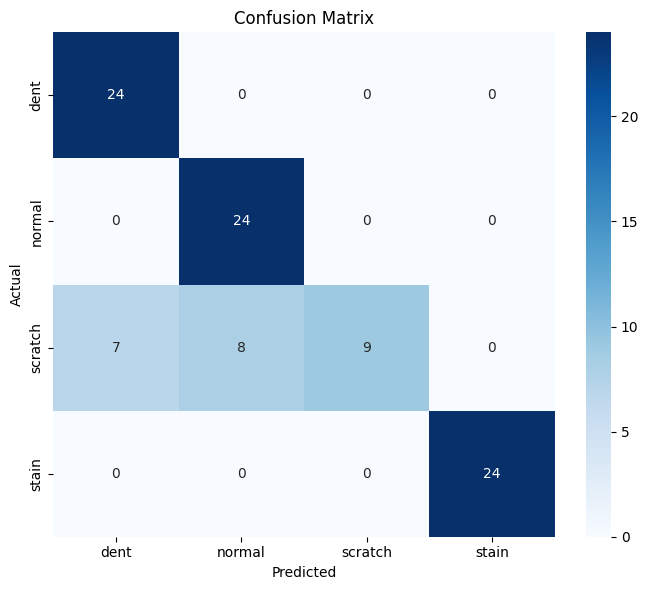


Classification Report:
              precision    recall  f1-score   support

        dent       0.77      1.00      0.87        24
      normal       0.75      1.00      0.86        24
     scratch       1.00      0.38      0.55        24
       stain       1.00      1.00      1.00        24

    accuracy                           0.84        96
   macro avg       0.88      0.84      0.82        96
weighted avg       0.88      0.84      0.82        96

All evaluation plots saved!


In [14]:
# Evaluation - Accuracy/Loss Curves + Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Val Loss', marker='s')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('results/accuracy_loss_curves.png', dpi=100, bbox_inches='tight')
plt.show()

# Confusion Matrix
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))
print("All evaluation plots saved!")

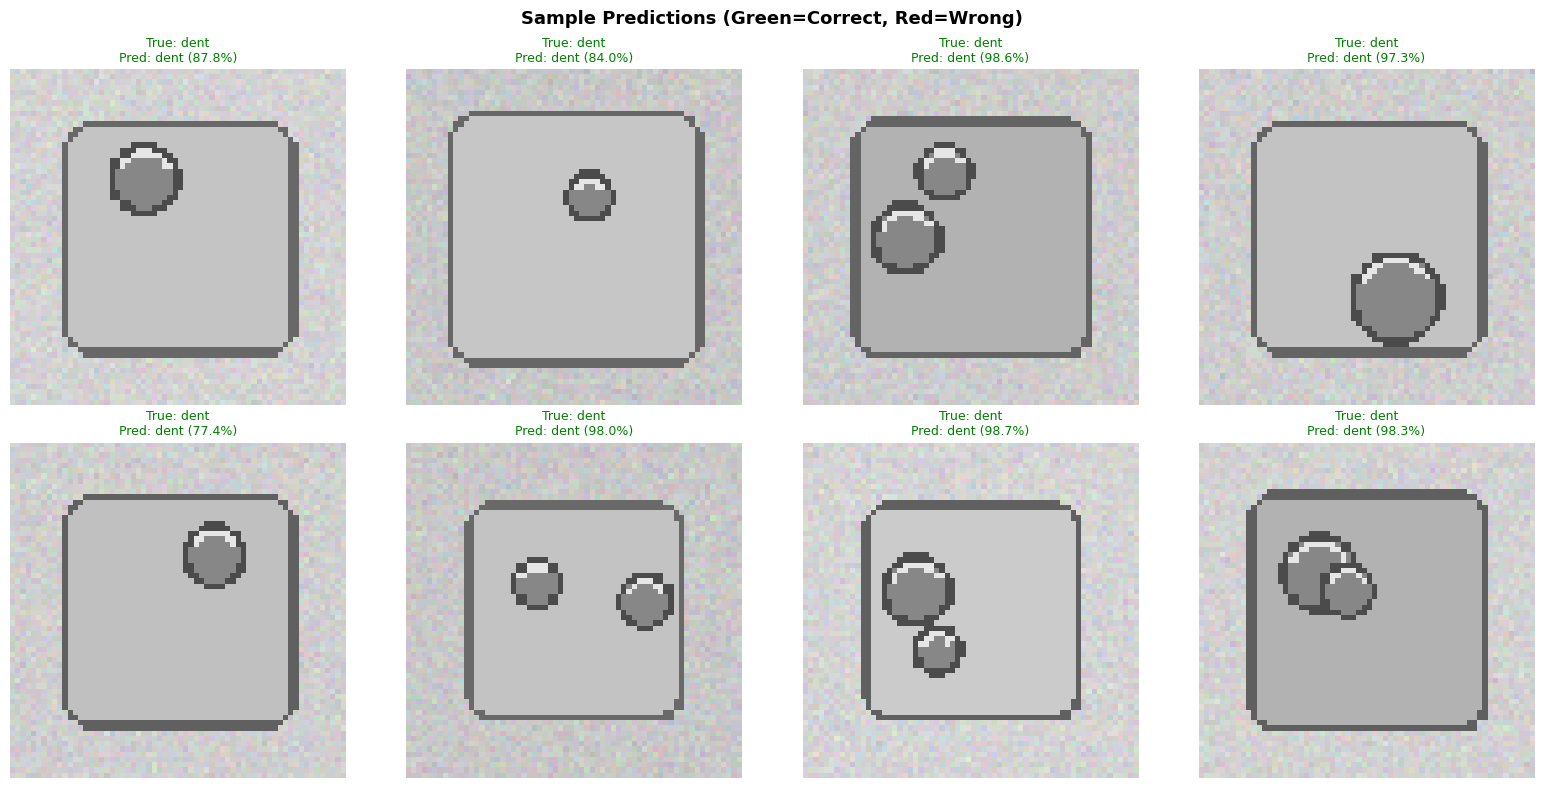

Sample predictions saved!


In [15]:
# Sample Predictions on Test Images
test_generator.reset()
images_batch, labels_batch = next(test_generator)
predictions = model.predict(images_batch, verbose=0)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    img = images_batch[i]
    true_label = class_names[np.argmax(labels_batch[i])]
    pred_label = class_names[np.argmax(predictions[i])]
    confidence = np.max(predictions[i]) * 100

    axes[i].imshow(img)
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
                      color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png', dpi=100, bbox_inches='tight')
plt.show()
print("Sample predictions saved!")

In [16]:
# Download all output files
from google.colab import files

files.download('results/sample_class_images.png')
files.download('results/accuracy_loss_curves.png')
files.download('results/confusion_matrix.png')
files.download('sample_predictions/prediction_outputs.png')

print("\nNotebook bhi download karo:")
print("File → Download → Download .ipynb")
print("\nDone! Ab README aur requirements.txt banao.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Notebook bhi download karo:
File → Download → Download .ipynb

Done! Ab README aur requirements.txt banao.
